In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch
from PIL import Image

In [2]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Manchester United 1-2 Leeds - Premier League 2025_2026 Live.html"
fotmob_matchId = 4813691

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)


In [3]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [4]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [5]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [6]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [7]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,relatedPlayerId,blockedX,blockedY,goalMouthZ,goalMouthY,isShot,isGoal,cardType,teamName,oppositionTeamName
0,2.923865e+09,3,0,0.0,19,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leeds,Man Utd
1,2.923865e+09,3,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Leeds
2,2.923865e+09,4,0,0.0,32,59.88,40.32,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Leeds
3,2.923865e+09,5,0,3.0,32,29.40,39.12,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Leeds
4,2.923865e+09,4,0,9.0,19,30.72,67.76,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leeds,Man Utd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,2.923919e+09,904,97,3.0,32,0.00,0.00,100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Leeds
1617,2.923919e+09,855,0,0.0,19,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leeds,Man Utd
1618,2.923919e+09,905,0,0.0,32,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Leeds
1619,2.923822e+09,2,0,0.0,19,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leeds,Man Utd


In [8]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,402184,31,Senne Lammens,GK,True,S. Lammens
1,349932,3,Noussair Mazraoui,DR,True,N. Mazraoui
2,340105,6,Lisandro Martínez,DC,True,L. Martínez
3,437299,15,Leny Yoro,DC,True,L. Yoro
4,118244,23,Luke Shaw,DL,True,L. Shaw
5,88526,18,Casemiro,DMC,True,Casemiro
6,408962,25,Manuel Ugarte,DMC,True,M. Ugarte
7,386634,16,Amad Diallo,AMR,True,A. Diallo
8,123761,8,Bruno Fernandes,AMC,True,B. Fernandes
9,362758,10,Matheus Cunha,AML,True,M. Cunha


In [9]:
df = df.merge(dfp, on='playerId', how='left')

In [10]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [11]:
df=df.reset_index()

In [12]:
df

,index,id,eventId,minute,second,teamId,x,y,expandedMinute,period,...,isShot,isGoal,cardType,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2,2.923865e+09,4,0,0.0,32,59.88,40.32,0,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,8.0,Bruno Fernandes,AMC,True,B. Fernandes
1,3,2.923865e+09,5,0,3.0,32,29.40,39.12,0,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,31.0,Senne Lammens,GK,True,S. Lammens
2,4,2.923865e+09,4,0,9.0,19,30.72,67.76,0,NaN,...,NaN,NaN,NaN,Leeds,Man Utd,5.0,Pascal Struijk,DC,True,P. Struijk
3,5,2.923865e+09,6,0,10.0,32,63.24,21.84,0,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,18.0,Casemiro,DMC,True,Casemiro
4,6,2.923865e+09,7,0,10.0,32,68.52,26.88,0,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,25.0,Manuel Ugarte,DMC,True,M. Ugarte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1126,1607,2.923919e+09,851,96,52.0,19,15.84,34.80,99,NaN,...,NaN,NaN,NaN,Leeds,Man Utd,26.0,Karl Darlow,GK,True,K. Darlow
1127,1608,2.923919e+09,900,96,52.0,32,93.84,49.76,99,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,2.0,Diogo Dalot,Sub,NaN,D. Dalot
1128,1609,2.923919e+09,901,96,56.0,32,85.92,41.28,99,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,8.0,Bruno Fernandes,AMC,True,B. Fernandes
1129,1610,2.923919e+09,902,96,59.0,32,84.60,9.68,99,NaN,...,NaN,NaN,NaN,Man Utd,Leeds,25.0,Manuel Ugarte,DMC,True,M. Ugarte


In [13]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [14]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,59.88,40.32,28.44,42.08,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,3.0,29.40,39.12,76.80,12.08,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
2,0,9.0,30.72,67.76,58.32,54.72,Leeds,5.0,DC,P. Struijk,NaN,NaN,NaN
3,0,10.0,63.24,21.84,68.52,26.88,Man Utd,18.0,DMC,Casemiro,NaN,NaN,NaN
4,0,10.0,68.52,26.88,55.92,60.32,Man Utd,25.0,DMC,M. Ugarte,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1126,96,52.0,15.84,34.80,27.72,23.04,Leeds,26.0,GK,K. Darlow,NaN,NaN,NaN
1127,96,52.0,93.84,49.76,85.92,41.76,Man Utd,2.0,Sub,D. Dalot,NaN,NaN,NaN
1128,96,56.0,85.92,41.28,84.60,9.84,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1129,96,59.0,84.60,9.68,90.60,15.44,Man Utd,25.0,DMC,M. Ugarte,NaN,NaN,NaN


In [15]:
team1=df[df["teamName"]=="Man Utd"]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,59.88,40.32,28.44,42.08,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,3.0,29.40,39.12,76.80,12.08,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
3,0,10.0,63.24,21.84,68.52,26.88,Man Utd,18.0,DMC,Casemiro,NaN,NaN,NaN
4,0,10.0,68.52,26.88,55.92,60.32,Man Utd,25.0,DMC,M. Ugarte,NaN,NaN,NaN
5,0,14.0,57.48,64.40,71.16,61.52,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,96,11.0,84.72,13.28,104.16,33.44,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1125,96,47.0,79.20,39.84,104.16,45.20,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1127,96,52.0,93.84,49.76,85.92,41.76,Man Utd,2.0,Sub,D. Dalot,NaN,NaN,NaN
1128,96,56.0,85.92,41.28,84.60,9.84,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN


In [16]:
team2=df[df["teamName"]=="Leeds"]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
2,0,9.0,30.72,67.76,58.32,54.72,Leeds,5.0,DC,P. Struijk,NaN,NaN,NaN
16,0,58.0,47.16,66.56,37.44,46.48,Leeds,5.0,DC,P. Struijk,NaN,NaN,NaN
17,1,0.0,37.08,44.24,48.60,21.60,Leeds,15.0,DC,J. Bijol,NaN,NaN,NaN
18,1,7.0,48.60,21.60,64.20,20.40,Leeds,24.0,DC,J. Justin,NaN,NaN,NaN
19,1,9.0,64.20,20.40,46.20,24.00,Leeds,11.0,AMC,B. Aaronson,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,95,33.0,75.60,60.64,70.44,60.00,Leeds,29.0,Sub,W. Gnonto,NaN,NaN,NaN
1115,95,38.0,67.08,72.08,82.68,73.52,Leeds,3.0,DML,G. Gudmundsson,NaN,NaN,NaN
1124,96,15.0,16.56,49.36,46.80,49.92,Leeds,4.0,MC,E. Ampadu,NaN,NaN,NaN
1126,96,52.0,15.84,34.80,27.72,23.04,Leeds,26.0,GK,K. Darlow,NaN,NaN,NaN


In [17]:
firstSub1=70

In [18]:
team1=team1[team1["minute"]<firstSub1]
team1

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,59.88,40.32,28.44,42.08,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,3.0,29.40,39.12,76.80,12.08,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
3,0,10.0,63.24,21.84,68.52,26.88,Man Utd,18.0,DMC,Casemiro,NaN,NaN,NaN
4,0,10.0,68.52,26.88,55.92,60.32,Man Utd,25.0,DMC,M. Ugarte,NaN,NaN,NaN
5,0,14.0,57.48,64.40,71.16,61.52,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,67,51.0,100.68,53.68,NaN,NaN,Man Utd,10.0,AML,M. Cunha,42.08,True,NaN
818,68,13.0,119.40,0.40,116.16,40.32,Man Utd,16.0,AMR,A. Diallo,NaN,NaN,NaN
820,68,19.0,88.44,14.96,113.40,49.04,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
821,68,23.0,113.40,49.04,NaN,NaN,Man Utd,18.0,DMC,Casemiro,38.64,True,True


In [19]:
firstSub2=74

In [20]:
team2=team2[team2["minute"]<firstSub2]
team2

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
2,0,9.0,30.72,67.76,58.32,54.72,Leeds,5.0,DC,P. Struijk,NaN,NaN,NaN
16,0,58.0,47.16,66.56,37.44,46.48,Leeds,5.0,DC,P. Struijk,NaN,NaN,NaN
17,1,0.0,37.08,44.24,48.60,21.60,Leeds,15.0,DC,J. Bijol,NaN,NaN,NaN
18,1,7.0,48.60,21.60,64.20,20.40,Leeds,24.0,DC,J. Justin,NaN,NaN,NaN
19,1,9.0,64.20,20.40,46.20,24.00,Leeds,11.0,AMC,B. Aaronson,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,71,24.0,61.08,53.52,57.00,32.48,Leeds,4.0,MC,E. Ampadu,NaN,NaN,NaN
846,71,26.0,56.88,32.48,46.80,46.56,Leeds,24.0,DC,J. Justin,NaN,NaN,NaN
847,71,29.0,46.80,46.56,50.04,55.76,Leeds,15.0,DC,J. Bijol,NaN,NaN,NaN
848,71,32.0,56.88,54.56,48.00,72.32,Leeds,22.0,MC,A. Tanaka,NaN,NaN,NaN


In [22]:
response=requests.get("https://www.sofascore.com/football/match/manchester-united-leeds-united/JsK#id:14025024,tab:statistics")

In [23]:
soup=BeautifulSoup(response.text,"html.parser")

In [24]:
soup.select('g[cursor="pointer"]')

[]

In [25]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9,hi;q=0.8',
    'referer': 'https://www.sofascore.com/football/match/manchester-united-leeds-united/JsK',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
}

url='https://www.sofascore.com/api/v1/event/14025024/shotmap'

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [26]:
shots=response.json()

In [27]:
df_shots=pd.json_normalize(shots["shotmap"])

In [28]:
df_shots

,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,addedTime,...,draw.end.x,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,goalType
0,True,miss,corner,right-foot,high,0.009022,0.000000,7068605,90,1.0,...,46.6,0,46.6,18.1,NaN,NaN,NaN,NaN,NaN,NaN
1,False,block,throw-in-set-piece,right-foot,low-centre,0.095807,0.000000,7068598,88,NaN,...,51.6,0,51.6,81.0,10.1,50.7,0.0,50.7,10.1,NaN
2,True,block,corner,right-foot,low-centre,0.173706,0.000000,7068593,85,NaN,...,50.6,0,50.6,81.0,1.9,49.6,0.0,49.6,1.9,NaN
3,True,save,corner,head,low-left,0.169641,0.000000,7068594,85,NaN,...,47.6,0,47.6,81.0,0.6,48.2,0.0,48.2,0.6,NaN
4,True,block,regular,left-foot,low-right,0.025707,0.000000,7068604,85,NaN,...,53.1,0,53.1,81.0,8.0,34.1,0.0,34.1,8.0,NaN
5,True,save,assisted,head,high-centre,0.139271,0.432361,7068591,85,NaN,...,48.7,0,48.7,74.1,1.6,50.4,0.0,50.4,1.6,NaN
6,False,miss,fast-break,left-foot,high,0.026320,0.000000,7068542,82,NaN,...,46.4,0,46.4,26.4,NaN,NaN,NaN,NaN,NaN,NaN
7,True,save,assisted,right-foot,low-right,0.045530,0.066991,7068537,80,NaN,...,52.5,0,52.5,86.7,1.4,53.6,0.0,53.6,1.4,NaN
8,True,block,assisted,left-foot,low-centre,0.065433,0.000000,7068536,79,NaN,...,49.7,0,49.7,81.0,8.4,60.1,0.0,60.1,8.4,NaN
9,False,save,assisted,head,low-centre,0.250877,0.133084,7068534,78,NaN,...,49.2,0,49.2,96.8,0.9,49.6,0.0,49.6,0.9,NaN


In [29]:
df_shots=df_shots.sort_values("time").reset_index()
df_shots

,index,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,...,draw.end.x,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,goalType
0,34,False,save,assisted,right-foot,low-centre,0.639682,0.442099,7067970,3,...,49.0,0,49.0,98.7,1.9,49.3,0.0,49.3,1.9,NaN
1,33,False,goal,regular,right-foot,low-right,0.137687,0.428371,7067979,5,...,51.9,0,51.9,98.7,NaN,NaN,NaN,NaN,NaN,regular
2,32,True,save,assisted,left-foot,low-left,0.022661,0.049232,7068007,12,...,47.7,0,47.7,91.8,1.5,50.9,0.0,50.9,1.5,NaN
3,31,True,miss,corner,head,high,0.028229,0.000000,7068015,16,...,49.9,0,49.9,11.1,NaN,NaN,NaN,NaN,NaN,NaN
4,30,True,save,fast-break,right-foot,low-centre,0.074820,0.069958,7068019,17,...,51.0,0,51.0,97.5,2.0,49.1,0.0,49.1,2.0,NaN
5,29,True,miss,assisted,left-foot,left,0.021040,0.000000,7068084,19,...,34.5,0,34.5,94.4,NaN,NaN,NaN,NaN,NaN,NaN
6,28,False,miss,corner,head,high-right,0.038614,0.000000,7068100,24,...,58.7,0,58.7,29.2,NaN,NaN,NaN,NaN,NaN,NaN
7,27,False,block,assisted,right-foot,low-left,0.140710,0.000000,7068117,28,...,47.3,0,47.3,81.0,4.7,53.6,0.0,53.6,4.7,NaN
8,26,False,block,assisted,left-foot,low-centre,0.097642,0.000000,7068122,29,...,49.3,0,49.3,81.0,10.3,47.7,0.0,47.7,10.3,NaN
9,25,False,goal,assisted,right-foot,low-right,0.022230,0.370517,7068153,29,...,53.5,0,53.5,84.8,NaN,NaN,NaN,NaN,NaN,regular


In [30]:
df_shots=df_shots[["isHome","shotType","xg","time","player.shortName","player.jerseyNumber","playerCoordinates.x","playerCoordinates.y",
        "goalMouthCoordinates.x","goalMouthCoordinates.y"]]

In [31]:
df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
df_shots["goalMouthCoordinates.x"]=df_shots["goalMouthCoordinates.x"]*1.2
df_shots["goalMouthCoordinates.y"]=df_shots["goalMouthCoordinates.y"]*0.8

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\3668136620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\3668136620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\3668136620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [32]:
for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==False):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
    if (df_shots["isHome"][x]==True):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\4112479664.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
C:\Users\K Raghunandan\AppData\Local\Temp\ipy

In [33]:
team1_shots=df_shots[df_shots["isHome"]==True]
team1_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
2,True,save,0.022661,12,A. Diallo,16,27.00,32.08,0.0,41.84
3,True,miss,0.028229,16,L. Yoro,15,10.68,34.80,0.0,40.08
4,True,save,0.074820,17,B. Šeško,30,18.96,45.28,0.0,39.20
5,True,miss,0.021040,19,A. Diallo,16,16.92,24.56,0.0,52.40
11,True,miss,0.007394,36,M. Cunha,10,29.28,54.00,0.0,39.76
13,True,miss,0.014970,44,N. Mazraoui,3,30.36,28.64,0.0,31.44
16,True,save,0.099851,48,B. Šeško,30,12.48,45.44,0.0,40.48
17,True,block,0.047282,48,M. Ugarte,25,15.60,42.24,0.0,38.80
18,True,block,0.016823,51,B. Fernandes,8,21.48,55.52,0.0,42.00
21,True,save,0.168383,65,L. Yoro,15,7.68,39.28,0.0,36.64


In [34]:
team2_shots=df_shots[df_shots["isHome"]==False]
team2_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,False,save,0.639682,3,D. Calvert-Lewin,9,5.88,41.04,0.0,40.80
1,False,goal,0.137687,5,N. Okafor,19,11.52,45.52,0.0,38.48
6,False,miss,0.038614,24,J. Bijol,15,11.88,38.80,0.0,33.04
7,False,block,0.140710,28,D. Calvert-Lewin,9,7.68,35.36,0.0,42.16
8,False,block,0.097642,29,B. Aaronson,11,14.40,42.08,0.0,40.56
9,False,goal,0.022230,29,N. Okafor,19,23.28,51.04,0.0,37.20
10,False,block,0.089534,33,P. Struijk,5,7.32,45.68,0.0,42.24
12,False,miss,0.251341,40,D. Calvert-Lewin,9,9.84,40.88,0.0,52.88
14,False,save,0.586441,45,A. Tanaka,22,3.24,42.72,0.0,41.68
15,False,save,0.136372,45,P. Struijk,5,7.92,39.28,0.0,39.92


In [35]:
a_xG=[0]
h_xG=[0]
a_min=[0]
h_min=[0]

for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==True):
        h_xG.append(df_shots["xg"][x])
        h_min.append(df_shots["time"][x])
    if (df_shots["isHome"][x]==False):
        a_xG.append(df_shots["xg"][x])
        a_min.append(df_shots["time"][x])

In [36]:
def nums_cumulative_sum(nums_list):
    return [sum(nums_list[:i+1]) for i in range(len(nums_list))]

a_cum=nums_cumulative_sum(a_xG)
h_cum=nums_cumulative_sum(h_xG)

In [37]:
a_total=round(a_cum[-1],2)
h_total=round(h_cum[-1],2)

In [38]:
def create_passnetwork(df, ax,color):
    df["passer"]=df["shirtNo"]
    df["recipient"]=df["shirtNo"].shift(-1)

    pas=pd.to_numeric(df["passer"],downcast="integer")
    rec=pd.to_numeric(df["recipient"],downcast="integer")

    df["passer"]=pas
    df["recipient"]=rec

    df=df.drop(["goalMouthY","isShot","isGoal"],axis=1)

    average_locations=df.groupby("passer").agg({"x":["mean"],"y":["mean","count"]})
    average_locations.columns=["x","y","count"]
    average_locations

    pass_between = (
    df
    .groupby(["passer", "recipient"])
    .size()
    .reset_index(name="pass_count")
    )

    pass_between = pass_between.merge(average_locations, left_on='passer', right_index=True)
    pass_between = pass_between.merge(average_locations, left_on='recipient', right_index=True, suffixes=['', '_end'])

    pass_between=pass_between[pass_between["pass_count"]>3]

    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A')
    pitch.draw(ax=ax)
    plt.gca().invert_xaxis()

    arrows=pitch.arrows(pass_between.x,
                        pass_between.y,
                        pass_between.x_end,
                        pass_between.y_end,
                        ax=ax,
                        width=4.2,
                        headwidth=4.2,
                        color=color,
                        alpha=.5)
    
    nodes=pitch.scatter(average_locations.x,
                    average_locations.y,
                    s=500,
                    color="#d3d3d3",
                    edgecolor="black",
                    linewidth=2.5,
                    alpha=1,
                    ax=ax)

    for passer, row in average_locations.iterrows():
        pitch.annotate(
            str(passer),
            xy=(row['x'], row['y']),
            ha='center',
            va='center',
            fontsize=9,
            color='black',
            weight='bold',
            ax=ax
        )

In [39]:
def create_xg_flowchart(df, ax, h_color, a_color):
    ax.patch.set_facecolor("#EAEAEA")
    
    plt.xticks([0,15,30,45,60,75,90])
    plt.xlabel("Minutes")
    plt.ylabel("xG")

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    df['cumulative_xG'] = df.groupby('isHome')['xg'].cumsum()

    ax.step(x=a_min,y=a_cum,where="post",color=a_color)
    ax.step(x=h_min,y=h_cum,where="post",color=h_color)

    for x in range(len(df["playerCoordinates.x"])):
        if (df["isHome"][x]==True):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=h_color,zorder=5)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
        if (df["isHome"][x]==False):
            if df["shotType"][x]=="goal":
                plt.scatter(y=df["cumulative_xG"][x],x=df["time"][x],color="#EAEAEA",s=100,edgecolors=a_color)
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.09,
                    df['player.shortName'][x],
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )
                ax.text(
                    df['time'][x],
                    df['cumulative_xG'][x] + 0.05,
                    str(df['time'][x])+"'",
                    ha='center',
                    va='center',
                    fontfamily='monospace',
                    fontsize=8,
                    zorder=10
                )

In [40]:
def create_shotmap(df, ax, color):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A',half=True)
    pitch.draw(ax=ax, constrained_layout=True, tight_layout=False)
    plt.gca().invert_yaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,45)

    for x in df.to_dict(orient='records'):
        if x['shotType'] == 'goal':
            pitch.plot((x["playerCoordinates.x"],x["goalMouthCoordinates.x"]),
                       (x["playerCoordinates.y"],x["goalMouthCoordinates.y"]),
                       color=color,
                       ax=ax,
                       alpha=0.7)
        pitch.scatter(
            x=x["playerCoordinates.x"], y=x["playerCoordinates.y"], ax=ax, 
            s=500 * x['xg'], 
            facecolor=color if x['shotType'] == 'goal' else "#EAEAEA", 
            edgecolors=color, alpha=0.7
        )

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\1998340895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["passer"]=df["shirtNo"]
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\1998340895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["recipient"]=df["shirtNo"].shift(-1)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_30580\1998340895.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

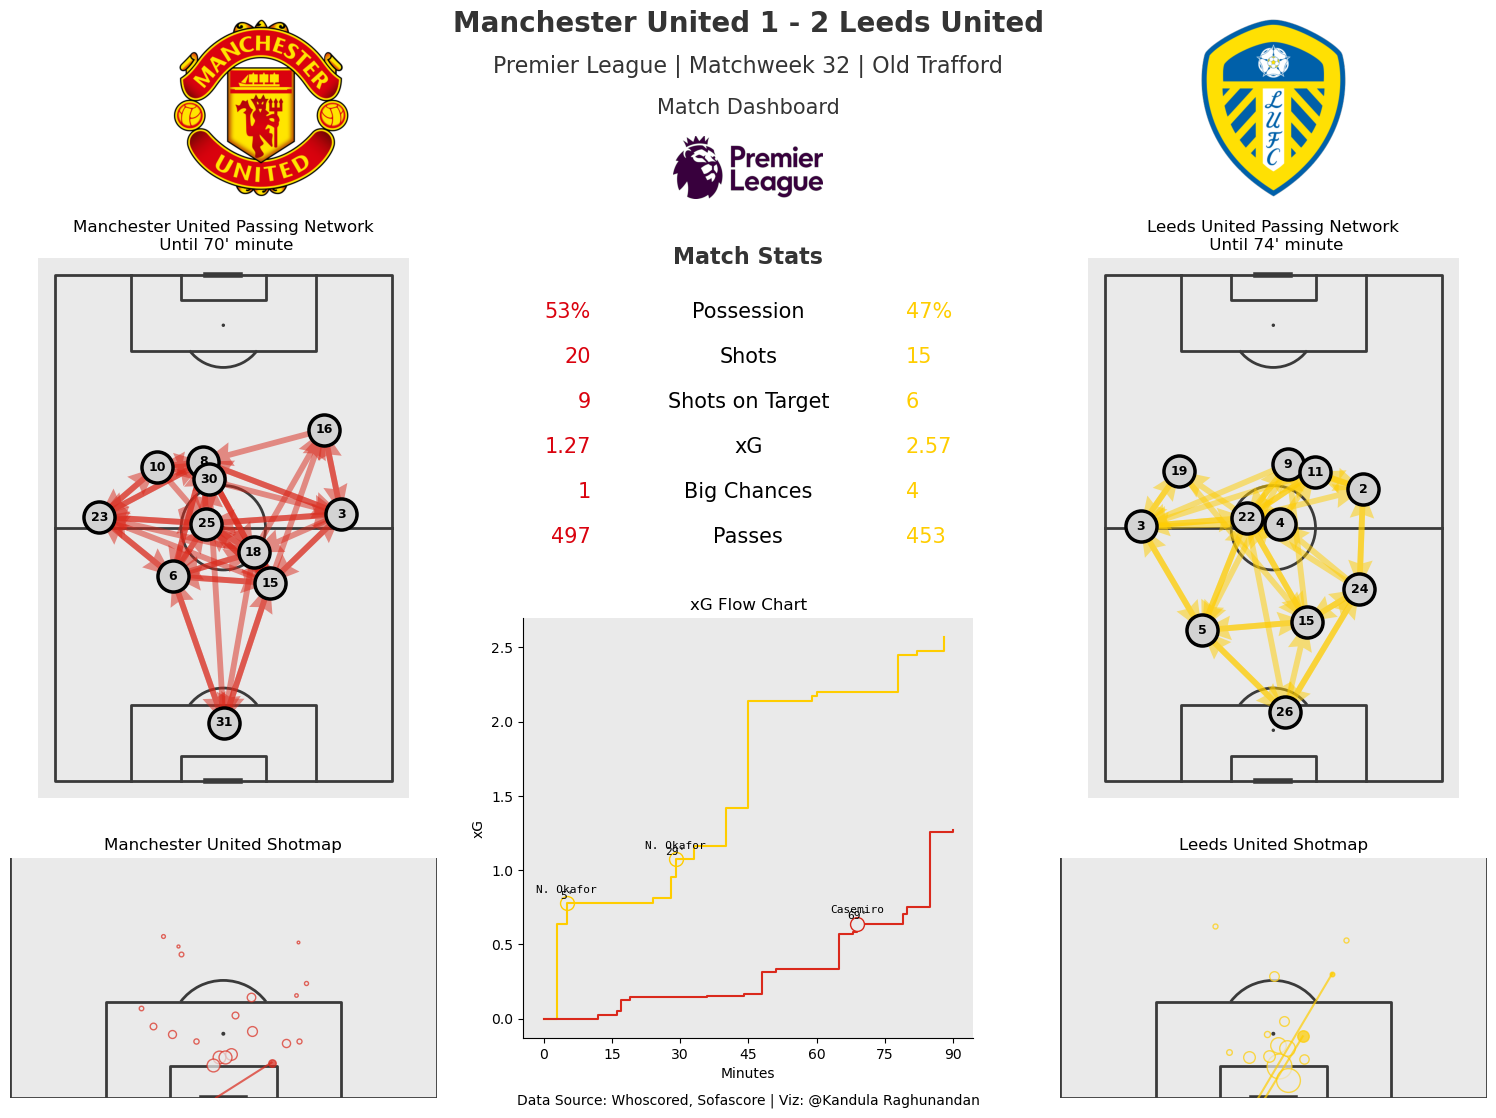

In [45]:
fig = plt.figure(figsize=(15,12))

ax1=fig.add_axes([0.25, 0.8, 0.15, 0.15])
team1_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png")
ax1.imshow(team1_img)
ax1.axis("off")

ax2=fig.add_axes([0.6, 0.775, 0.10, 0.10])
league_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")
ax2.imshow(league_img)
ax2.axis("off")

ax3=fig.add_axes([0.925, 0.8, 0.15, 0.15])
team2_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Leeds United.png")
ax3.imshow(team2_img)
ax3.axis("off")

ax4=fig.add_axes([.15,.3,.3,.45])
create_passnetwork(team1,ax4, "#DA291C")
ax4.set_title("Manchester United Passing Network\n Until 70' minute")

ax5=fig.add_axes([.5,.1,.3,.35])
create_xg_flowchart(df_shots, ax5, "#DA291C", "#FFCD00")
ax5.set_title("xG Flow Chart")

plt.text(
    0.5, -0.15, "Data Source: Whoscored, Sofascore | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="black"
)

ax6=fig.add_axes([.85,.3,.3,.45])
create_passnetwork(team2,ax6, "#FFCD00")
ax6.set_title("Leeds United Passing Network\n Until 74' minute")

ax7=fig.add_axes([.15,.05,.3,.2])
create_shotmap(team1_shots,ax7, "#DA291C")
ax7.set_title("Manchester United Shotmap")

ax8=fig.add_axes([.85,.05,.3,.2])
create_shotmap(team2_shots,ax8, "#FFCD00")
ax8.set_title("Leeds United Shotmap")

ax9 = fig.add_axes([.5,.3,.3,.5])
ax9.set_facecolor("#f7f7f7")
ax9.axis("off")

ax9.text(0.5, 0.9, "Match Stats", ha="center", va="center",
         fontsize=16, fontweight="bold",color="#343434")

labels = ["Possession", "Shots", "Shots on Target", "xG", "Big Chances", "Passes"]

y_positions = [0.8, 0.725, 0.65, 0.575, 0.50, 0.425]

home_vals = ["53%", 20, 9, 1.27, 1, 497]
away_vals = ["47%", 15, 6, 2.57, 4, 453]

for label, y, n_val, u_val in zip(labels, y_positions, home_vals, away_vals):

    ax9.text(0.5, y, label, ha="center", fontsize=15)
    ax9.text(0.15, y, str(n_val), ha="right", fontsize=15,color="#DA020E")
    ax9.text(0.85, y, str(u_val), ha="left", fontsize=15,color="#FFCD00")


fig.text(0.65, 0.945, "Manchester United 1 - 2 Leeds United", fontsize=20, fontweight='bold', color='#343434', ha="center", va="center")
fig.text(0.65, 0.91, "Premier League | Matchweek 32 | Old Trafford", fontsize=16, color='#343434', ha="center", va="center")
fig.text(0.65, 0.875, "Match Dashboard", fontsize=15, color='#343434', ha="center", va="center" )

fig.savefig("C:/Users/K Raghunandan/Analyst/Matches/Manchester United 1-2 Leeds - Premier League 2025_2026 Live_files/New folder/match_dashboard.png", bbox_inches='tight')